In [98]:
import pandas as pd

import matplotlib.pyplot as plt #provides plotting functions
import seaborn as sns #used for making graph and visualizations

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [99]:
df = pd.read_csv("diabetes.csv")

In [100]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [101]:
df.shape #768 Examples, 9 Features

(768, 9)

In [102]:
df.dtypes.value_counts() #Checking Data Types

int64      5
float64    4
Name: count, dtype: int64

In [103]:
df.isnull().sum() #No Missing Values

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

**Class Distribution Bar Chart**

In [104]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

Text(0.5, 1.0, 'Class Distribution')

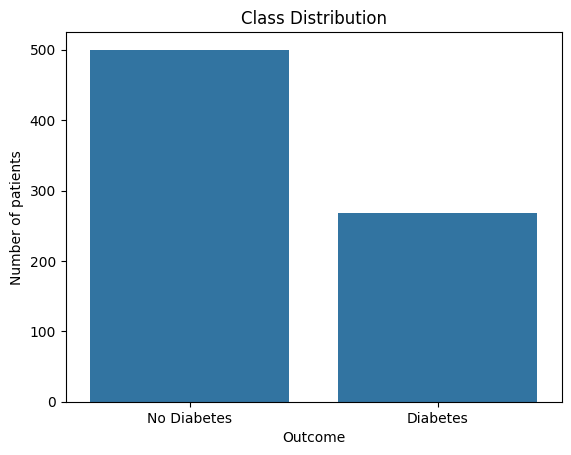

In [105]:
#Creating Class Distribution Bar Chart

#Count how many times each category appears and create bars for those counts.

sns.countplot(x="Outcome", data=df) # X-axis -> Outcome Column
plt.xticks([0, 1], ["No Diabetes", "Diabetes"]) #changes labels 0 and 1 to diabetic and non-diabetic
plt.ylabel("Number of patients")
plt.title("Class Distribution")

Imbalanced DataSet Mostly Non Diabetic Patient's Data

**SPLITTING DATA**

In [106]:
X = df.drop(['Outcome'], axis=1)
y = df['Outcome']

In [107]:
X.shape

(768, 8)

In [108]:
y.shape

(768,)

In [109]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [110]:
X_train.shape

(614, 8)

In [111]:
X_test.shape

(154, 8)

In [112]:
model1 = DecisionTreeClassifier(criterion='gini', max_depth=None, min_samples_leaf=1, random_state=42)

**FULLY-GROWN, DELIBERATELY OVERFIT TREE**

In [113]:
model1.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [114]:
y_pred1_test = model1.predict(X_test)
y_pred1_train = model1.predict(X_train)

In [115]:
print(f"Training Data: {((accuracy_score(y_train, y_pred1_train))*100):.2f}%")
print(f"Testing Data: {((accuracy_score(y_test, y_pred1_test))*100):.2f}%")

Training Data: 100.00%
Testing Data: 83.77%


Can clearly see that 100% Accuracy on Training Data means **OverFitting**

**TUNE VIA CROSS-VALIDATION**

In [116]:
param_grid={
    'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10, 20]
}

Using Strafied K Fold as Class is not equally distributed

Stratified K-Fold Cross Validation is a technique used for evaluating a model

StratifiedKFold tries to preserve the same class proportion in every fold.

It makes your model evaluation more reliable and fair.

In [117]:
model2 = DecisionTreeClassifier(random_state=42)

In [118]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) #5 Folds, Shuffle the data before splitting

grid = GridSearchCV(model2, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)

#scoring is metric used to compare different models, n_jobs=-1 means use all available CPU cores

In [119]:
grid.fit(X_train, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'max_depth': [1, 2, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [125]:
grid.best_params_ #Best Hyper Parameters

{'max_depth': 6, 'min_samples_leaf': 5, 'min_samples_split': 2}

In [128]:
print(f"{grid.best_score_ * 100:.2f}%") #Best Accuracy Score

86.16%


In [127]:
tuned_model = grid.best_estimator_ #Best classifier

In [123]:
y_pred2_test = tuned_model.predict(X_test)
y_pred2_train = tuned_model.predict(X_train)

In [124]:
print(f"Training Data: {((accuracy_score(y_train, y_pred2_train))*100):.2f}%")
print(f"Testing Data: {((accuracy_score(y_test, y_pred2_test))*100):.2f}%")

Training Data: 93.49%
Testing Data: 82.47%


**Test vs Train Accuracy Curve**

In [130]:
depths = range(1, 21)
train_accuracy, test_accuracy = [], []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, min_samples_leaf=1, random_state=42)
    model.fit(X_train, y_train)
    train_accuracy.append(accuracy_score(y_train, model.predict(X_train)))
    test_accuracy.append(accuracy_score(y_test, model.predict(X_test)))

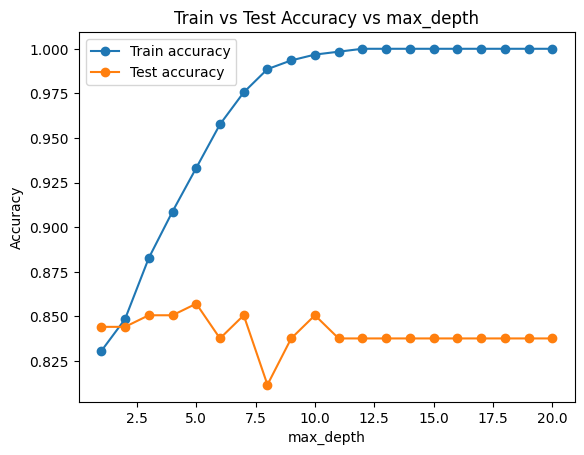

In [131]:
plt.plot(depths, train_accuracy, marker="o", label="Train accuracy")
plt.plot(depths, test_accuracy, marker="o", label="Test accuracy")

plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy vs max_depth")
plt.legend()

In [138]:
import numpy as np

best_depth_by_test = list(depths)[int(np.argmax(test_accuracy))]
print(f"\n[Plot 3] Test accuracy peaks at max_depth={best_depth_by_test} "
      f"(test acc={(max(test_accuracy)*100):.3f}%); train accuracy keeps climbing toward 1.0.")


[Plot 3] Test accuracy peaks at max_depth=5 (test acc=85.714%); train accuracy keeps climbing toward 1.0.


**COST COMPLEXITY PRUNING (CCP_APLHA)**